In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## DATOS DE VIOLENCIA

In [142]:
df_violencia = pd.read_csv("./violenciaIntrafamiliar.csv")
df_violencia = df_violencia.drop_duplicates()

#castear los datos que estan como objetct a numericos
df_violencia['MES_EMISION'] = pd.to_numeric(df_violencia['MES_EMISION'], errors='coerce')
df_violencia['VIC_EDAD'] = pd.to_numeric(df_violencia['VIC_EDAD'], errors='coerce')
df_violencia['VIC_EDAD'] = df_violencia['VIC_EDAD'].fillna(df_violencia['VIC_EDAD'].mean())
df_violencia['HEC_DIA'] = pd.to_numeric(df_violencia['HEC_DIA'], errors='coerce')
df_violencia['HEC_ANO'] = pd.to_numeric(df_violencia['HEC_ANO'], errors='coerce')
df_violencia['TOTAL_HIJOS'] = pd.to_numeric(df_violencia['TOTAL_HIJOS'], errors='coerce')
df_violencia['AGR_EDAD'] = df_violencia['AGR_EDAD'].replace("ignorado", np.nan)
df_violencia['AGR_EDAD'] = pd.to_numeric(df_violencia['AGR_EDAD'], errors='coerce')
df_violencia['AGR_EDAD'] = df_violencia['AGR_EDAD'].fillna(df_violencia['AGR_EDAD'].mean())
columns_to_clean = [
	"MES_EMISION", "DEPTO_MCPIO", "QUIEN_REPORTA", "VIC_SEXO", "VIC_EST_CIV",
	"VIC_GRUPET", "VIC_NACIONAL", "VIC_DISC", "VIC_REL_AGR", "OTRAS_VICTIMAS",
	"VIC_OTRAS_HOM", "VIC_OTRAS_MUJ", "VIC_OTRAS_N_OS", "VIC_OTRAS_N_AS",
	"HEC_MES", "HEC_AREA", "HEC_TIPAGRE", "HEC_RECUR_DENUN",
	"AGR_SEXO", "AGR_ALFAB", "AGR_NACIONAL", "AGR_TRABAJA", "INST_DENUN_HECHO"
] 

for col in columns_to_clean:
	if col in df_violencia.columns:
		df_violencia[col] = df_violencia[col].astype(str).str.strip().str.lower()
		
#convertir ninguna a 0
df_violencia['OTRAS_VICTIMAS'] = df_violencia['OTRAS_VICTIMAS'].replace({"ninguna": 0})
df_violencia['VIC_OTRAS_HOM'] = df_violencia['VIC_OTRAS_HOM'].replace({"ninguno": 0})
df_violencia['VIC_OTRAS_MUJ'] = df_violencia['VIC_OTRAS_MUJ'].replace({"ninguna": 0})
df_violencia['VIC_OTRAS_N_OS'] = df_violencia['VIC_OTRAS_N_OS'].replace({"ninguna": 0})
df_violencia['VIC_OTRAS_N_AS'] = df_violencia['VIC_OTRAS_N_AS'].replace({"ninguno": 0})

#convertir ignorado a la media
df_violencia['TOTAL_HIJOS'] = df_violencia['TOTAL_HIJOS'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_HOM'] = df_violencia['VIC_OTRAS_HOM'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_MUJ'] = df_violencia['VIC_OTRAS_MUJ'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_N_OS'] = df_violencia['VIC_OTRAS_N_OS'].fillna(df_violencia['TOTAL_HIJOS'].mean())
df_violencia['VIC_OTRAS_N_AS'] = df_violencia['VIC_OTRAS_N_AS'].fillna(df_violencia['TOTAL_HIJOS'].mean())

#convertir a numerico
df_violencia['OTRAS_VICTIMAS'] = pd.to_numeric(df_violencia['OTRAS_VICTIMAS'], errors='coerce')
df_violencia['VIC_OTRAS_HOM'] = pd.to_numeric(df_violencia['VIC_OTRAS_HOM'], errors='coerce')
df_violencia['VIC_OTRAS_MUJ'] = pd.to_numeric(df_violencia['VIC_OTRAS_MUJ'], errors='coerce')
df_violencia['VIC_OTRAS_N_OS'] = pd.to_numeric(df_violencia['VIC_OTRAS_N_OS'], errors='coerce')
df_violencia['VIC_OTRAS_N_AS'] = pd.to_numeric(df_violencia['VIC_OTRAS_N_AS'], errors='coerce')

df_violencia.shape

C:\Users\dgv31\AppData\Local\Temp\ipykernel_33644\3962652492.py:1: DtypeWarning: Columns (3,6,7,26,28,29,39,46,47,48,49,50,51,52,53,56,57,58,59,60,61,62,63,64,65,66,67,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df_violencia = pd.read_csv("./violenciaIntrafamiliar.csv")


(423630, 75)

## DATOS DE MATRIMONIO

In [143]:
df_matri = pd.read_csv("matrimonios.csv") 
columnas_validas = ['DEPREG','MUPREG','MESREG','AÑOREG','CLAUNI','EDADHOM','EDADMUJ','GETHOM','GETMUJ','NACHOM','NACMUJ','OCUHOM','OCUMUJ','NUPHON','NUPMUJ','DEPOCU','MUPOCU','MESOCU','AÑOOCU','AREAG']
df_matri = df_matri[columnas_validas]

# Eliminar datos vacios
cols_a_imputar = ["EDADHOM", "EDADMUJ", "NUPHON", "NUPMUJ"]
df_matri[cols_a_imputar] = df_matri[cols_a_imputar].replace("Ignorado", np.nan)
df_matri[cols_a_imputar] = df_matri[cols_a_imputar].apply(pd.to_numeric, errors="coerce")

df_matri.fillna({
    "MUPREG": "Ignorado",
    "MESREG": "Ignorado",
    "CLAUNI": "Ignorado",
    "GETHOM": "Ignorado",
    "GETMUJ": "Ignorado",
    "DEPREG": "Ignorado",
    "NACHOM": "Ignorado",
    "NACMUJ": "Ignorado",
    "OCUHOM": "Ignorado",
    "OCUMUJ": "Ignorado",
    "DEPOCU": "Ignorado",
    "MUPOCU": "Ignorado",
    "MESOCU": "Ignorado",
    "AREAG": "Ignorado"
}, inplace=True)

df_matri.fillna({
    "AÑOREG": df_matri["AÑOREG"].median(),
    "EDADHOM": df_matri["EDADHOM"].median(), 
    "EDADMUJ": df_matri["EDADMUJ"].median(),
    "NUPHON": df_matri["NUPHON"].median(),
    "NUPMUJ": df_matri["NUPMUJ"].median(), 
    "AÑOOCU": df_matri["AÑOOCU"].median()
}, inplace=True)

# Convertir todo a minúsculas y quitar espacios extra
df_matri["GETHOM"] = df_matri["GETHOM"].str.strip().str.lower()
df_matri["GETMUJ"] = df_matri["GETMUJ"].str.strip().str.lower()

df_matri.shape

C:\Users\dgv31\AppData\Local\Temp\ipykernel_33644\890111105.py:1: DtypeWarning: Columns (0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20,21,22,24,25,26,27,28,29,30,31,32,33,34,35,36,38,40,41,42,44,45,46,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df_matri = pd.read_csv("matrimonios.csv")


(974972, 20)

## Igualar variables

In [144]:
# Matrimonios
['DEPREG', 'MUPREG', 'EDADHOM', 'EDADMUJ', 'GETHOM', 'GETMUJ', 
 'NACHOM', 'NACMUJ', 'OCUHOM', 'OCUMUJ', 'DEPOCU', 'MUPOCU', 'AREAG']

# Violencia
['DEPTO_MCPIO', 'VIC_SEXO', 'VIC_EDAD', 'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
 'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP', 'HEC_DEPTOMCPIO', 'HEC_AREA']

['DEPTO_MCPIO',
 'VIC_SEXO',
 'VIC_EDAD',
 'AGR_SEXO',
 'AGR_EDAD',
 'VIC_GRUPET',
 'AGR_GRUPET',
 'VIC_NACIONAL',
 'AGR_NACIONAL',
 'VIC_OCUP',
 'AGR_OCUP',
 'HEC_DEPTOMCPIO',
 'HEC_AREA']

### Igualar sexo

In [145]:
df_violencia['VIC_SEXO'] = df_violencia['VIC_SEXO'].replace({
    'hombres': 'hombre',
    'mujeres': 'mujer'
})

df_violencia['VIC_SEXO'].unique()

array(['mujer', 'hombre'], dtype=object)

In [146]:
df_violencia['AGR_SEXO'] = df_violencia['AGR_SEXO'].replace({
    'hombres': 'hombre',
    'mujeres': 'mujer'
})

df_violencia['AGR_SEXO'].unique()

array(['hombre', 'mujer'], dtype=object)

### Igualar edad

In [147]:
edad_hombre = df_matri['EDADHOM'].dtype
edad_mujer = df_matri['EDADMUJ'].dtype
edad_victima = df_violencia['VIC_EDAD'].dtype
edad_agresor = df_violencia['AGR_EDAD'].dtype

print(edad_hombre)
print(edad_mujer)
print(edad_victima)
print(edad_agresor)

float64
float64
float64
float64


In [148]:
df_matri['EDADHOM'] = df_matri['EDADHOM'].astype(int)
edad_hombre = df_matri['EDADHOM'].unique()
df_matri['EDADMUJ'] = df_matri['EDADMUJ'].astype(int)
edad_mujer = df_matri['EDADMUJ'].unique()
df_violencia['VIC_EDAD'] = df_violencia['VIC_EDAD'].astype(int)
edad_victima = df_violencia['VIC_EDAD'].unique()
df_violencia['AGR_EDAD'] = df_violencia['AGR_EDAD'].astype(int)
edad_agresor = df_violencia['AGR_EDAD'].unique()

print(edad_hombre)
print(edad_mujer)
print(edad_victima)
print(edad_agresor)

[16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 37 43 45 46 60
 35 36 38 39 40 47 49 41 42 55 66 44 48 50 51 57 62 65 69 53 63 71 75 54
 56 58 59 52 83 61 64 68 67 79 70 82 76 77 78 72 73 81 74 80 93 85 87 86
 84 89 88 90 92 99 91 94 95 15 14 97 96 98]
[ 14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31
  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49
  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89 108 109  13  91  92  12  90  94  93  96  97  95  99]
[11  4  6  1 10  8  7  5  3  2  9 48 69 91 32 25 30 54 49 21 37 33 16 41
 43 19 35 15 26 29 17 31 46 28 18 50 24 38 57 22 79 53 40 14 52 23 39 60
 63 27 55 20 44 51 12 45 62 59 36 65 61 34 47 70 56 71 78 74 73 13 58 42
 68 77 83 80 75 76 67 66 64 72 88 85 87 81 92 84 89 86 82 94 90 96 93 95
 97]
[58 27 35 31 65 60 38 28 19 26 25 30 34 44 29 39 32 16 22 21 18 24 14 41
 33 4

In [149]:
df_violencia['VIC_EDADMUJ'] = np.where(df_violencia['VIC_SEXO'] == 'mujer', df_violencia['VIC_EDAD'], np.nan)
df_violencia['VIC_EDADHOM'] = np.where(df_violencia['VIC_SEXO'] == 'hombre', df_violencia['VIC_EDAD'], np.nan)
df_violencia['AGR_EDADMUJ'] = np.where(df_violencia['AGR_SEXO'] == 'mujer', df_violencia['AGR_EDAD'], np.nan)
df_violencia['AGR_EDADHOM'] = np.where(df_violencia['AGR_SEXO'] == 'hombre', df_violencia['AGR_EDAD'], np.nan)

df_violencia[['VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']].count()

VIC_EDADMUJ    378554
VIC_EDADHOM     45076
AGR_EDADMUJ     55247
AGR_EDADHOM    368383
dtype: int64

### Igualar etnia

In [150]:
df_matri['GETHOM'].unique()

array(['indigena', 'ignorado', 'no indigena'], dtype=object)

In [151]:
df_matri['GETMUJ'].unique()

array(['indigena', 'ignorado', 'no indigena'], dtype=object)

In [152]:
df_violencia['VIC_GRUPET'].unique()

array(['ladinos(as)', 'ignorado', 'mayas', 'no indica', 'otros', 'xincas',
       'garifunas', 'xinkas', 'maya', 'otro', 'garifuna', 'xinka',
       'xinca'], dtype=object)

In [153]:
df_violencia['VIC_GRUPET'] = df_violencia['VIC_GRUPET'].replace({
    'ladinos(as)': 'ladino',
    'mayas': 'maya',
    'garifunas': 'garifuna',
    'xincas': 'xinka',
    'xinkas': 'xinka',
    'xinca': 'xinka',
    'no indica': 'ignorado',
    'otros': 'otro'
})

df_violencia['VIC_GRUPET'].unique()

array(['ladino', 'ignorado', 'maya', 'otro', 'xinka', 'garifuna'],
      dtype=object)

In [154]:
df_violencia['VIC_GRUPET'] = df_violencia['VIC_GRUPET'].replace({
    'ladino': 'no indigena',
    'maya': 'indigena',
    'garifuna': 'indigena',
    'xinka': 'indigena',
    'otro': 'no indigena'
})

df_violencia['VIC_GRUPET'].unique()

array(['no indigena', 'ignorado', 'indigena'], dtype=object)

In [155]:
df_violencia['AGR_GRUPET'].unique()

array([nan, 'Ladinos(as)', 'Mayas', 'Ignorado', 'No indica', 'Otros',
       'Xinkas', 'Garifunas', 'Maya', 'Otro', 'Xinka', 'Garifuna'],
      dtype=object)

In [156]:
df_violencia["AGR_GRUPET"] = df_violencia["AGR_GRUPET"].str.strip().str.lower()

In [157]:
df_violencia['AGR_GRUPET'] = df_violencia['AGR_GRUPET'].replace({
    'ladinos(as)': 'ladino',
    'mayas': 'maya',
    'garifunas': 'garifuna',
    'xinkas': 'xinka',
    'no indica': 'ignorado',
    'otros': 'otro'
})

df_violencia.fillna({"AGR_GRUPET": "ignorado"}, inplace=True)



In [158]:
df_violencia['AGR_GRUPET'] = df_violencia['AGR_GRUPET'].replace({
    'ladino': 'no indigena',
    'maya': 'indigena',
    'garifuna': 'indigena',
    'xinka': 'indigena',
    'otro': 'no indigena'
})

In [159]:
df_violencia['AGR_GRUPET'].unique()

array(['ignorado', 'no indigena', 'indigena'], dtype=object)

### Igualar nacionalidad

In [160]:
nac_hom = df_matri['NACHOM'].unique()
nac_muj = df_matri['NACMUJ'].unique()
nac_vic = df_violencia['VIC_NACIONAL'].unique()
nac_agr = df_violencia['AGR_NACIONAL'].unique()

print(f"Nacionalidad hombre:\n{nac_hom}")
print(f"Nacionalidad mujer:\n{nac_muj}")
print(f"Nacionalidad victima:\n{nac_vic}")
print(f"Nacionalidad agresor:\n{nac_agr}")

Nacionalidad hombre:
['Guatemala' 'México' 'Estados Unidos de América' 'Nicaragua'
 'El Salvador' 'Ignorado' 'Honduras' 'Canadá' 'Argentina' 'Cuba' 'Suecia'
 'Chile' 'Costa Rica' 'España' 'Colombia' 'Puerto Rico e Islas Vírgenes'
 'República Dominicana' 'Gran Bretaña'
 'Dinamarca, Checoslovaquia, Polonia, Bélgica, Inglaterra)'
 'Otros Países (Grecia, Austria, Rumania, Viena, Noruega,' 'Perú'
 'Otros Países (Hong Kong, Rusia,' 'Bolivia' 'Otros (Trinidad y Tobago)'
 'Venezuela' 'India' 'Francia' 'Alemania' 'Panamá y Zona del Canal'
 'Japón' 'Italia' 'Suiza' 'Otros (Paraguay y Uruguay)' 'Ecuador' 'Belice'
 'Jordania, Hawaii, Singapore, Vietnam, Korea)' 'Africa'
 'Israel (Jerusalén)' 'Holanda' 'Filipinas' 'Jamaica' 'Australia'
 'Zimbawe del Norte' 'República de Libano' 'Israel' 'Bélgica' 'Austria'
 'Brasil' 'Irlanda' 'Uruguay' 'Turquia' 'Croacia' 'Noruega' 'Jordania'
 'Puerto Rico' 'Rusia' 'China' 'Corea Del Sur' 'Siria'
 'República de China (Taiwan)' 'Rumania' 'Paraguay' 'Bahamas' 'Libano

In [161]:
def clasificar_nacionalidad(valor):
    if pd.isna(valor):
        return 'ignorado'
    valor = valor.strip().lower()
    if valor == 'guatemala':
        return 'guatemalteca'
    elif 'ignorado' in valor:
        return 'ignorado'
    else:
        return 'extranjera'

df_matri['NACHOM'] = df_matri['NACHOM'].apply(clasificar_nacionalidad)
df_matri['NACMUJ'] = df_matri['NACMUJ'].apply(clasificar_nacionalidad)

### Igualar ocupación

Frecuencia de VIC_OCUP:
VIC_OCUP
Vendedores no clasificados bajo otros epígrafes                             11.740036
Limpiadores y asistentes domésticos                                          9.047038
Agricultores y trabajadores calificados de cultivos extensivos               5.942549
Maestros de enseñanza primaria                                               5.421903
Peones de explotaciones agrícolas                                            3.633034
                                                                              ...    
Operadores de máquinas para fabricar cemento y otros productos minerales     0.000718
Controladores de tráfico aéreo                                               0.000718
Operadores de máquinas para fabricar productos de papel                      0.000718
Operadores de instalaciones de procesamiento de metales                      0.000718
Técnicos en química industrial                                               0.000718
Name: proportion, Len

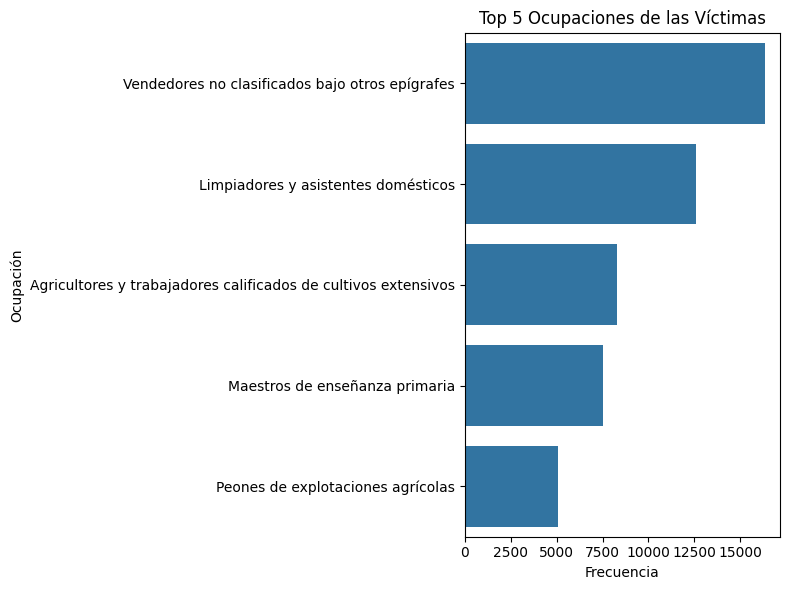

In [162]:
print("Frecuencia de VIC_OCUP:")
print(df_violencia['VIC_OCUP'].value_counts(normalize=True) * 100)


top_5_ocupaciones = df_violencia['VIC_OCUP'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=df_violencia['VIC_OCUP'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de las Víctimas")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

Frecuencia de AGR_OCUP:
AGR_OCUP
Agricultores y trabajadores calificados de cultivos extensivos                18.373333
Peones de explotaciones agrícolas                                             12.124595
Vendedores no clasificados bajo otros epígrafes                                7.474557
Mozos de labranza y peones agropecuarios                                       6.980252
Conductores de automóviles, taxis y camionetas                                 5.071608
                                                                                ...    
Ensambladores de equipos eléctricos y electrónicos                             0.000297
Trabajadores de explotaciones de acuicultura                                   0.000297
Controladores de tráfico aéreo                                                 0.000297
Especialistas en políticas de administración                                   0.000297
Profesionales del nivel medio de servicios jurídicos sociales y religiosos     0.000297

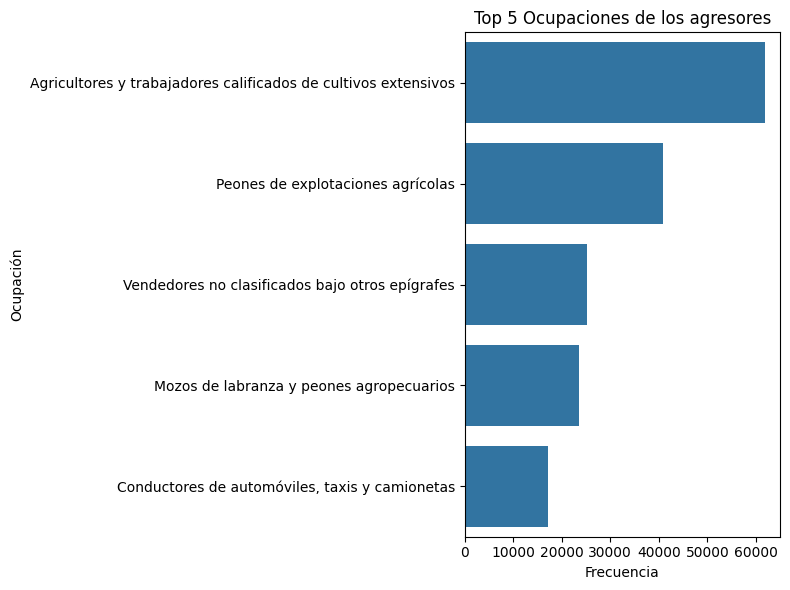

In [163]:
print("Frecuencia de AGR_OCUP:")
print(df_violencia['AGR_OCUP'].value_counts(normalize=True) * 100)


top_5_ocupaciones = df_violencia['AGR_OCUP'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=df_violencia['AGR_OCUP'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de los agresores")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

Frecuencia de AGR_DEDICA:
AGR_DEDICA
Quehaceres del Hogar              53.109192
Ignorado                          23.295497
Desempleado                       10.888341
Estudiar                           5.986428
Vive de sus Renta o Jubilación     4.115978
Otro                               2.160395
Alcohólico/Drogadicto              0.444170
Name: proportion, dtype: float64


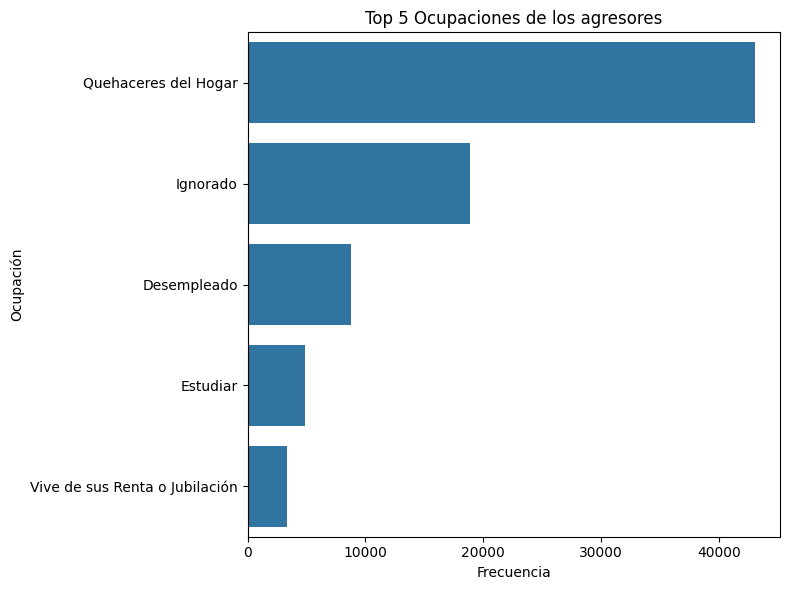

In [164]:
print("Frecuencia de AGR_DEDICA:")
print(df_violencia['AGR_DEDICA'].value_counts(normalize=True) * 100)


top_5_ocupaciones = df_violencia['AGR_DEDICA'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=df_violencia['AGR_DEDICA'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de los agresores")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

Frecuencia de VIC_DEDICA:
VIC_DEDICA
Quehaceres del hogar              93.782622
Estudiar                           3.523275
Ignorado                           1.472667
Vive de sus renta o jubilación     0.851142
Desempleado                        0.260800
Otro                               0.103824
Alcohólico/drogadicto              0.005670
Name: proportion, dtype: float64


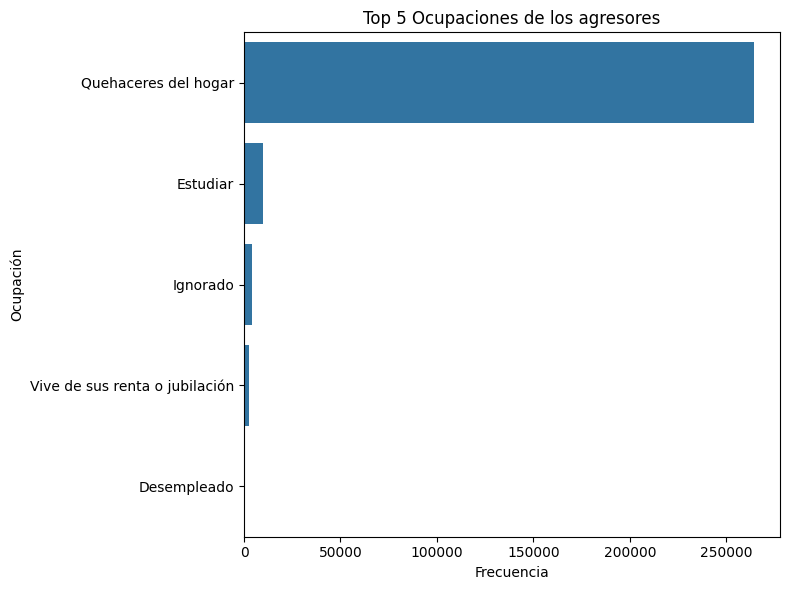

In [165]:
print("Frecuencia de VIC_DEDICA:")
print(df_violencia['VIC_DEDICA'].value_counts(normalize=True) * 100)


top_5_ocupaciones = df_violencia['VIC_DEDICA'].value_counts().nlargest(5).index

# Graficar
plt.figure(figsize=(8, 6))
sns.countplot(y=df_violencia['VIC_DEDICA'], order=top_5_ocupaciones)
plt.title("Top 5 Ocupaciones de los agresores")
plt.xlabel("Frecuencia")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

### Igualar departamentos / municipios

In [166]:
depto_muni_rep = df_violencia['DEPTO_MCPIO'].unique()
depto_muni_hech = df_violencia['HEC_DEPTOMCPIO'].unique()
muni_ocu = df_matri['MUPOCU'].unique()
dep_ocu = df_matri['DEPOCU'].unique()
dep_reg = df_matri['DEPREG'].unique()
muni_reg = df_matri['MUPREG'].unique()

print(f"Municipio reporte\n{depto_muni_rep}")
print(f"Municipio hecho\n{depto_muni_hech}")
print(f"Municipio registro\n{muni_reg}")
print(f"Departamento registro\n{dep_reg}")
print(f"Municipio ocurrencia\n{muni_ocu}")
print(f"Departamento ocurrencia\n{dep_ocu}")


Municipio reporte
['guatemala' 'guastatoya' 'san cristóbal acasaguastlán' 'sansare'
 'san marcos' 'cubulco' 'poptún' 'mazatenango' 'villa canales' 'escuintla'
 'retalhuleu' 'zacapa' 'san rafael las flores' 'sololá' 'san felipe'
 'gualán' 'pastores' 'tucurú' 'jocotán' 'san pedro pinula' 'mixco'
 'momostenango' 'chiquimula' 'san lorenzo' 'cobán' 'morales' 'comalapa'
 'taxisco' 'san andrés semetabaj' 'samayac' 'uspantán' 'purulhá'
 'el jícaro' 'san lucas toliman' 'quetzaltenango'
 'santo domingo suchitepéquez' 'san juan erminta' 'san josé el golfo'
 'san pablo la laguna' 'villa nueva' 'quesada' 'zunilito' 'jalapa'
 'chinautla' 'san pedro sacatepéquez' 'san juan sacatepéquez' 'morazán'
 'san agustín acasaguastlán' 'sanarate' 'jocotenango' 'antigua guatemala'
 'san lucas sacatepéquez' 'santa catarina barahona' 'chimaltenango'
 'san josé poaquil' 'san martín jilotepeque' 'tecpán guatemala' 'yepocapa'
 'tiquisate' 'palín' 'barberena' 'casillas' 'oratorio'
 'santa maría ixhuatán' 'pueblo nuevo

In [167]:
df_matri['MUPOCU'] = df_matri['MUPOCU'].astype(str).str.strip().str.lower()
df_matri['DEPOCU'] = df_matri['DEPOCU'].astype(str).str.strip().str.lower()
df_matri['DEPREG'] = df_matri['DEPREG'].astype(str).str.strip().str.lower()
df_matri['MUPREG'] = df_matri['MUPREG'].astype(str).str.strip().str.lower()
df_violencia['HEC_DEPTOMCPIO'] = df_violencia['HEC_DEPTOMCPIO'].astype(str).str.strip().str.lower()
df_violencia = df_violencia.rename(columns={'HEC_DEPTOMCPIO': 'HEC_MUNI', 'DEPTO_MCPIO': 'REP_MUNI'})

In [168]:
import re

df_violencia['REP_MUNI'] = df_violencia['REP_MUNI'].apply(
    lambda x: "ignorado" if pd.to_numeric(x, errors='coerce') is not pd.NA and not pd.isna(pd.to_numeric(x, errors='coerce')) else x
)
df_violencia['HEC_MUNI'] = df_violencia['HEC_MUNI'].apply(
    lambda x: "ignorado" if pd.to_numeric(x, errors='coerce') is not pd.NA and not pd.isna(pd.to_numeric(x, errors='coerce')) else x
)
df_matri['MUPOCU'] = df_matri['MUPOCU'].apply(
    lambda x: "ignorado" if re.fullmatch(r'[\d\.-]+', str(x)) else x
)


In [169]:
mupocu_dict = df_matri.set_index('MUPOCU')['DEPOCU'].to_dict()

def obtener_departamento(muni):
    if muni == "ignorado":
        return "ignorado"
    return mupocu_dict.get(muni, "ignorado")

df_violencia['REP_DEP'] = df_violencia['REP_MUNI'].apply(obtener_departamento)
df_violencia['HEC_DEP'] = df_violencia['HEC_MUNI'].apply(obtener_departamento)



In [170]:
depto_muni_rep = df_violencia['REP_MUNI'].unique()
depto_muni_hech = df_violencia['HEC_MUNI'].unique()
muni_ocu = df_matri['MUPOCU'].unique()
dep_ocu = df_matri['DEPOCU'].unique()
dep_reg = df_matri['DEPREG'].unique()
muni_reg = df_matri['MUPREG'].unique()
dep_rep = df_violencia['REP_DEP'].unique()
dep_hech = df_violencia['HEC_DEP'].unique()

print(f"Municipio reporte\n{depto_muni_rep}")
print(f"Departamento reporte\n{dep_rep}")
print(f"Municipio hecho\n{depto_muni_hech}")
print(f"Departamento hecho\n{dep_hech}")
print(f"Municipio registro\n{muni_reg}")
print(f"Departamento registro\n{dep_reg}")
print(f"Municipio ocurrencia\n{muni_ocu}")
print(f"Departamento ocurrencia\n{dep_ocu}")

Municipio reporte
['guatemala' 'guastatoya' 'san cristóbal acasaguastlán' 'sansare'
 'san marcos' 'cubulco' 'poptún' 'mazatenango' 'villa canales' 'escuintla'
 'retalhuleu' 'zacapa' 'san rafael las flores' 'sololá' 'san felipe'
 'gualán' 'pastores' 'tucurú' 'jocotán' 'san pedro pinula' 'mixco'
 'momostenango' 'chiquimula' 'san lorenzo' 'cobán' 'morales' 'comalapa'
 'taxisco' 'san andrés semetabaj' 'samayac' 'uspantán' 'purulhá'
 'el jícaro' 'san lucas toliman' 'quetzaltenango'
 'santo domingo suchitepéquez' 'san juan erminta' 'san josé el golfo'
 'san pablo la laguna' 'villa nueva' 'quesada' 'zunilito' 'jalapa'
 'chinautla' 'san pedro sacatepéquez' 'san juan sacatepéquez' 'morazán'
 'san agustín acasaguastlán' 'sanarate' 'jocotenango' 'antigua guatemala'
 'san lucas sacatepéquez' 'santa catarina barahona' 'chimaltenango'
 'san josé poaquil' 'san martín jilotepeque' 'tecpán guatemala' 'yepocapa'
 'tiquisate' 'palín' 'barberena' 'casillas' 'oratorio'
 'santa maría ixhuatán' 'pueblo nuevo

### Igualar área geográfica

In [171]:
df_matri['AREAG'] = df_matri['AREAG'].astype(str).str.strip().str.lower()
df_matri['AREAG'] = df_matri['AREAG'].replace({
    'urbano': 'urbana'
})
area_matri = df_matri['AREAG'].unique()

area_violencia = df_violencia['HEC_AREA'].unique()

print(area_matri)
print(area_violencia)

['ignorado' 'urbana' 'rural']
['urbana' 'ignorado' 'rural']


## Resultados

In [176]:
df_violencia['VIC_REL_AGR'].unique()

array(['hijos(as)', 'esposos(a)', 'conviviente', 'ex-cónyuges',
       'otro pariente', 'padres/madres', 'hermanos(as)', 'suegros(as)',
       'nietos(as)', 'hijastros(as)'], dtype=object)

In [177]:
df_violencia = df_violencia[(df_violencia['ANO_EMISION'] >= 2017) & (df_violencia['VIC_REL_AGR'] == 'esposos(a)')]
df_violencia.head()

,ANO_EMISION,MES_EMISION,DIA_EMISION,REP_MUNI,QUIEN_REPORTA,VIC_SEXO,VIC_EDAD,TOTAL_HIJOS,NUM_HIJ_HOM,NUM_HIJ_MUJ,...,ARTICULOTRAS4,ORGANISMO_REMITE,filter_$,NUMERO_BOLETA,VIC_EDADMUJ,VIC_EDADHOM,AGR_EDADMUJ,AGR_EDADHOM,REP_DEP,HEC_DEP
266725,2017.0,nan,3.0,ignorado,víctima,mujer,31,1.0,Ninguna,01,...,NaN,7.0,Not Selected,NaN,31.0,NaN,NaN,39.0,ignorado,ignorado
266726,2017.0,nan,4.0,ignorado,víctima,mujer,31,4.0,02,02,...,NaN,7.0,Not Selected,NaN,31.0,NaN,NaN,35.0,ignorado,ignorado
266733,2017.0,nan,19.0,ignorado,víctima,mujer,54,2.0,01,01,...,NaN,7.0,Not Selected,NaN,54.0,NaN,NaN,55.0,ignorado,ignorado
266737,2017.0,nan,23.0,ignorado,víctima,mujer,33,3.0,03,Ninguna,...,NaN,7.0,Not Selected,NaN,33.0,NaN,NaN,36.0,ignorado,ignorado
266742,2017.0,nan,27.0,ignorado,víctima,mujer,28,2.0,01,01,...,NaN,7.0,Not Selected,NaN,28.0,NaN,NaN,25.0,ignorado,ignorado


In [178]:
df_violencia.tail()

,ANO_EMISION,MES_EMISION,DIA_EMISION,REP_MUNI,QUIEN_REPORTA,VIC_SEXO,VIC_EDAD,TOTAL_HIJOS,NUM_HIJ_HOM,NUM_HIJ_MUJ,...,ARTICULOTRAS4,ORGANISMO_REMITE,filter_$,NUMERO_BOLETA,VIC_EDADMUJ,VIC_EDADHOM,AGR_EDADMUJ,AGR_EDADHOM,REP_DEP,HEC_DEP
423629,2021.0,nan,27.0,ignorado,víctima,mujer,50,12.0000,08,04,...,NaN,NaN,NaN,48.0,50.0,NaN,NaN,56.0,ignorado,ignorado
423631,2021.0,nan,19.0,ignorado,víctima,mujer,27,5.0000,05,Ninguna,...,NaN,NaN,NaN,50.0,27.0,NaN,NaN,29.0,ignorado,ignorado
423633,2021.0,nan,10.0,ignorado,víctima,mujer,33,1.0000,01,Ninguna,...,NaN,1.0,NaN,52.0,33.0,NaN,NaN,30.0,ignorado,ignorado
423634,2021.0,nan,13.0,ignorado,víctima,mujer,34,1.0000,01,Ninguna,...,NaN,1.0,NaN,53.0,34.0,NaN,NaN,35.0,ignorado,ignorado
423645,2021.0,nan,19.0,ignorado,víctima,mujer,23,2.5307,Ignorado,Ignorado,...,NaN,17.0,NaN,64.0,23.0,NaN,NaN,27.0,ignorado,ignorado


In [174]:
df_matri.head()

,DEPREG,MUPREG,MESREG,AÑOREG,CLAUNI,EDADHOM,EDADMUJ,GETHOM,GETMUJ,NACHOM,NACMUJ,OCUHOM,OCUMUJ,NUPHON,NUPMUJ,DEPOCU,MUPOCU,MESOCU,AÑOOCU,AREAG
0,san marcos,comitancillo,Abril,2010.0,Matrimonio,16,14,indigena,indigena,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,san marcos,comitancillo,Septiembre,2009.0,ignorado
1,retalhuleu,retalhuleu,Mayo,2009.0,Matrimonio,16,14,ignorado,ignorado,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,1.0,1.0,retalhuleu,retalhuleu,Marzo,2009.0,ignorado
2,huehuetenango,chiantla,Enero,2010.0,Matrimonio,16,14,ignorado,ignorado,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,1.0,1.0,huehuetenango,chiantla,Diciembre,2009.0,ignorado
3,quiche,joyabaj,Agosto,2009.0,Matrimonio,16,14,indigena,indigena,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,1.0,1.0,quiche,joyabaj,Julio,2009.0,ignorado
4,quiche,joyabaj,Octubre,2009.0,Matrimonio,16,14,indigena,indigena,guatemalteca,guatemalteca,Agricultores y trabajadores calificados de cul...,Oficios domésticos no remunerados,1.0,1.0,quiche,joyabaj,Octubre,2009.0,ignorado


In [175]:
df_matri.tail()

,DEPREG,MUPREG,MESREG,AÑOREG,CLAUNI,EDADHOM,EDADMUJ,GETHOM,GETMUJ,NACHOM,NACMUJ,OCUHOM,OCUMUJ,NUPHON,NUPMUJ,DEPOCU,MUPOCU,MESOCU,AÑOOCU,AREAG
974967,guatemala,villa nueva,Abril,2021.0,Comunidad de gananciales,94,54,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,guatemala,villa nueva,Abril,2021.0,ignorado
974968,santa rosa,taxisco,Julio,2021.0,Comunidad de gananciales,95,69,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,santa rosa,taxisco,Julio,2021.0,ignorado
974969,suchitepéquez,san francisco zapotitlán,Agosto,2021.0,Comunidad de gananciales,95,69,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,escuintla,nueva concepción,Junio,2021.0,ignorado
974970,guatemala,guatemala,Octubre,2021.0,Comunidad absoluta,98,72,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,guatemala,guatemala,Septiembre,2021.0,ignorado
974971,guatemala,guatemala,Febrero,2022.0,Comunidad de gananciales,99,71,ignorado,ignorado,guatemalteca,guatemalteca,Ignorado,Ignorado,1.0,1.0,guatemala,guatemala,Noviembre,2021.0,ignorado


In [179]:
# Guardar df_matri en matri_unite_data.csv
df_matri.to_csv('matri_unite_data.csv', index=False)

# Guardar df_violencia en violencia_unite_data.csv
df_violencia.to_csv('violencia_unite_data.csv', index=False)